In [1]:
using Revise

In [2]:
push!(LOAD_PATH,"../");
using TurbulenceFlux

[ Info: Precompiling TurbulenceFlux [801b548d-990e-47f8-8ae3-484f64b6e2ab]


In [3]:
include("plotrecipes.jl");

# Tips for non Julia users
 - to install dependencies from `TurbulenceFlux`, use 
  ```{julia}
  import Pkg;
  Pkg.activate("../") # Switch to `TurbulenceFlux` environement
  Pkg.instantiate() # Install all required packages
  Pkg.activate() # Switch back to default env.
  ```
 - to install packages such as `JLD2` or `DataFrames` use `import Pkg;Pkg.add("JLD2");Pkg.add("DataFrames")`
 - to write unicode characters in Julia such as β (in code edition or prompt mode) use backslash followed by tab to get a list of corresponding unicode caracters

# Data Loading

Some data samples are made available at https://drive.proton.me/urls/BWE0EVPWRW#5QSVcGrAQ0tr. To run the notebook on the data: download it and put the file under `data/` at the root directory of this package.

In [4]:
# Restricted use for users with a read access to Hesse private data server
#push!(LOAD_PATH,"../../HesseWork.jl")
#using HesseWork
#(all_days,load_data)=hesse_load_data();
#data=load_data(all_days[5]);

In [5]:
using JLD2
using DataFrames
data_sample=load("../data/data_sample.jld2")
days=collect(keys(data_sample))
data=data_sample[days[4]];

In [6]:
work_dim=length(data["Signals"].Date)
time_h=(0:(work_dim-1))
time_h=time_h ./ (60*60*20)
sampling_1min=1:60*20:work_dim;
sampling_30min=1:60*20*30:work_dim

1:36000:1692001

# Checking Signals

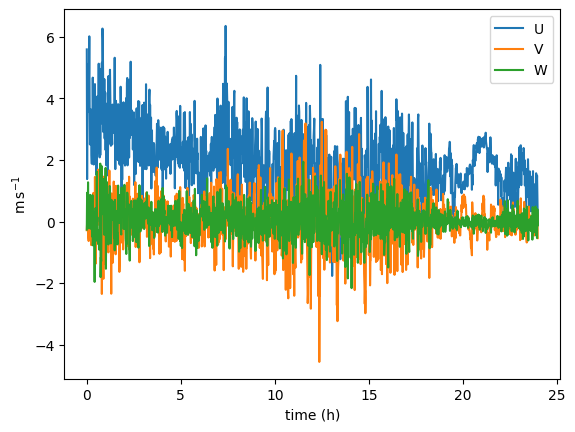

In [7]:
plot_speeds(data["Signals"]);

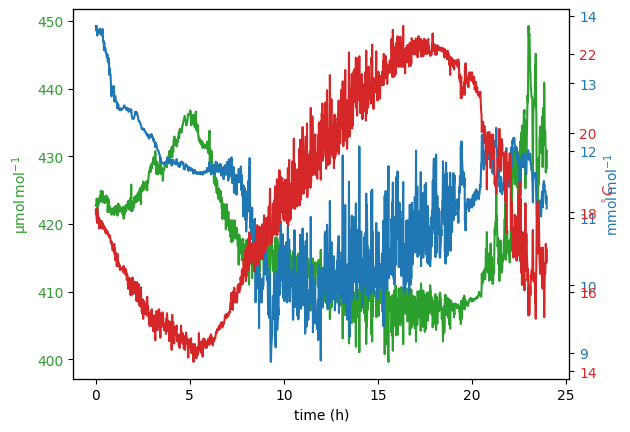

In [8]:
plot_scalars(data["Signals"]);

In [9]:
(;H_UNCORR,LE_UNCORR,FC_UNCORR)=data["EddyProFlux"];
time_EP = time_h[sampling_30min] .+ 15*60*20/work_dim # Center each 30 frames of flux estimation from eddypro at 15min

0.010416666666666666:0.5:23.510416666666668

In [10]:
(;U,V,W,T,CO2,H2O,P)=data["Signals"];
# some conversions
T=T .+ 274.15 # °C TO K
P=1000*P; # kPa to Pa

# Time-Scale Decomposition

## Choosing appropriate time-scale decomposition parameters

In [11]:
?TurbulenceFlux.init_averaging_conv_kernel

```
init_averaging_conv_kernel(work_dim;kernel_type,kernel_params,Δt,kernel_dim)
```

Initiliaze an averaging convolutional kernel.

# Arguments

  * `work_dim::Integer`: Input dimension
  * `kernel_dim::Integer`: Maximmum time support for the averaging kernel
  * `kernel_type::Symbol`: Type of kernel used for the averaging kernel
  * `kernel_params::Vector`: Vector of parameters for the averaging kernel
  * `Δt::Integer`: Time Sampling step of the output flux.


In [12]:
fs=20; # SAMPLING FREQUENCY
Δt=60*20 # 1min time sampling
kernel_dim=6*60*60*fs # 6h of max time support
σ=10*60*fs/kernel_dim # Gaussian reaches 0.6 at 10min
time_params=(kernel_type=:gaussian,kernel_dim=kernel_dim,kernel_params=[σ],Δt=Δt);

In [13]:
?TurbulenceFlux.init_wave_conv_kernel

```
init_wave_conv_kernel(work_dim;β,γ,J,Q,wmin,wmax,wave_dim,fs=1)
```

Initialize a wavelet convolutional kernel.

# Arguments

  * `work_dim::Integer`: Input dimension
  * `wave_dim::Integer`: maximum time support in time index of wavelets
  * `β::Float64`: First shape parameter of Generalized Morse Wavelets
  * `γ::Float64`: Second shape parameter
  * `J::Integer`: Number of frequency octaves
  * `Q::Integer`: Number of frequency inter-octaves
  * `wmin::Float64`: Minimum frequency peak allowed (in pulsation)
  * `wmax::Float64`: Maximum and starting frequency peak allowed (in pulsation)
  * `fs=1`: Sampling frequency


In [14]:
wave_dim=6*60*60*20 # 6h of max time support 
scale_params=(β=2,γ=3,J=25,Q=4,wmin=2*pi/wave_dim,wmax=pi,fs=fs,wave_dim=wave_dim);

In [15]:
?timescale_flux_decomp

search: timescale_flux_decomp



```
timescale_flux_decomp(w,θ,time_params,scale_params;with_info=false)
```

Compute the time-scale decomposition of the flux `wθ` given averaging and wavelet kernel parameters `time_params` and `scale_params` .

`w` and `θ` are real input vectors of the same size. The flux is computed using:

$$
F_{w\theta}(u,\xi) = \langle w * \psi_\xi , (\theta * \psi _xi ) \phi_u
$$

where $\phi_u$ is the averaging kernel centered at time $u$ and $\psi_\xi$ a wavelet with parameters $\xi$

# Arguments

  * `w::Vector`: First signal (e.g. the vertical wind speed)
  * `θ::Vector`: Second signal (e.g. temperature)
  * `time_params::NamedTuple`: Named Tuple of the parameters for initializing the averaging convolutional kernel `\phi`, see `init_averaging_conv_kernel`
  * `scale_params::NamedTuple`: Named Tuple of parameters for initializing the wavelet convolutional kernel `\psi`, see `init_wave_conv_kernel`
  * `with_info::Bool=false`: Output informations about the decomposition

# Examples

```julia
wave_dim=1024
kernel_dim=512
params=(
  wave_dim=wave_dim, β=1, γ=3, J=8, Q=8, wmin=2*pi/wave_dim, wmax=pi,
  kernel_dim=kernel_dim, kernel_type=:gaussian, kernel_params=[2.0], Δt=4)

F=timescale_flux_decomp(w,θ;params...)
```


In [16]:
time_sampling,freq_peak,decomp_CO2=timescale_flux_decomp(W,CO2,time_params,scale_params)
_,_,decomp_T=timescale_flux_decomp(W,T,time_params,scale_params)
_,_,decomp_H2O=timescale_flux_decomp(W,H2O,time_params,scale_params);

## Wavelets Visualisation

Number of filters: 67


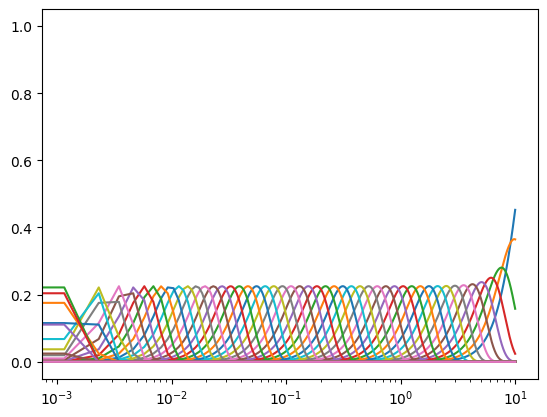

In [17]:
# Some Visual of the wavelets in frequency ( play with β, γ and wmin ! )
scale_params_test=(β=2,γ=3,J=25,Q=4,wmin=5pi/wave_dim,wmax=pi,fs=fs,wave_dim=wave_dim);
_,wave_params,WaveC=init_wave_conv_kernel(work_dim;scale_params_test...)
println("Number of filters: $(length(wave_params))")
waves= [ WaveC(vcat(1,zeros(work_dim-1)),ξ) for ξ in wave_params]
using FFTW
waves_fft=rfft.(waves)
freq_sampling=1:100:length(waves_fft[1])
freqs=range(0,fs/2,length=length(waves_fft[1]))[freq_sampling]
f=figure()
for wave in waves_fft
    plot(freqs,abs2.(wave)[freq_sampling])
end
xscale("log");

## Visualisation Time-Scale Flux Decomposition

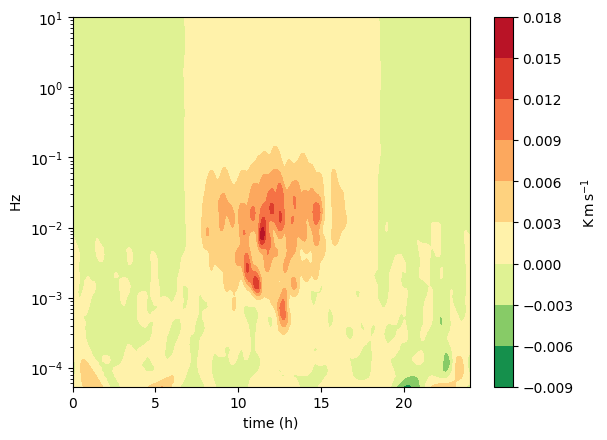

In [18]:
plot_contour(time_h[time_sampling],freq_peak[1:end-1],decomp_T[:,1:end-1]';label_z=label_T_rawflux);

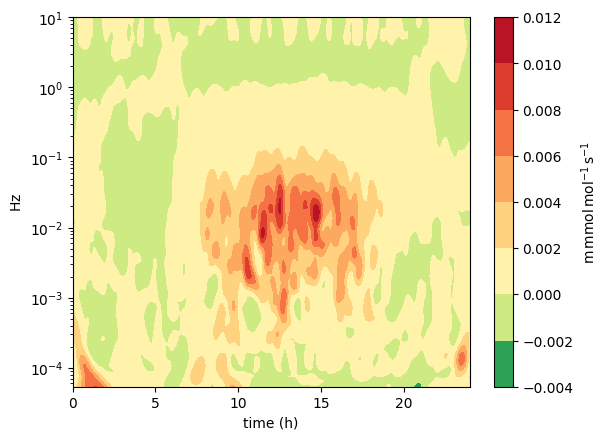

In [19]:
plot_contour(time_h[time_sampling],freq_peak[1:end-1],decomp_H2O[:,1:end-1]';label_z=label_h2o_rawflux);

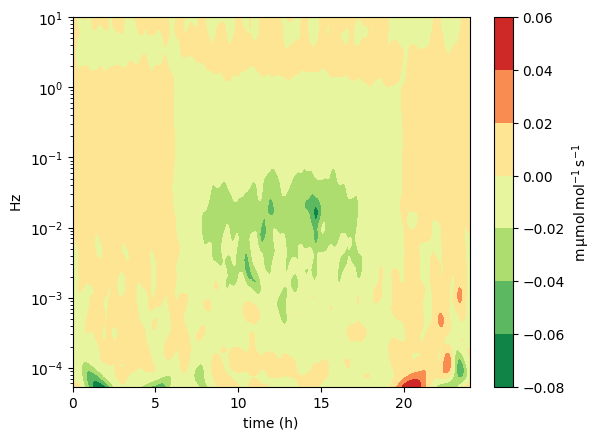

In [20]:
plot_contour(time_h[time_sampling],freq_peak[1:end-1],decomp_CO2[:,1:end-1]';label_z=label_co2_rawflux);

## Visualisation Time-Normalized Scale Flux Decomposition

In [21]:
# Prepare mean wind amplitude signal
time_params_mean_wind=(kernel_type=:gaussian,kernel_dim=kernel_dim,kernel_params=[60*60*fs/work_dim],Δt=Δt);
mean_wind = compute_wind_amplitude(U,V,W,time_params_mean_wind);

In [22]:
## Visualisation with log normalized frequency
ref_dist= 10 # Distance of reference in meters
to_η(i_t,j_ξ) = log((ref_dist*freq_peak[j_ξ])/mean_wind[i_t]);
S=(length(time_sampling),length(freq_peak))
CI=CartesianIndices((length(time_sampling),length(freq_peak)))
t=map(c->time_h[time_sampling[c[1]]],CI)
η=map(c->to_η(c[1],c[2]),CI)
mask=trues(size(decomp_T))
mask_nomean = copy(mask)
mask_nomean[:,end] .= false;

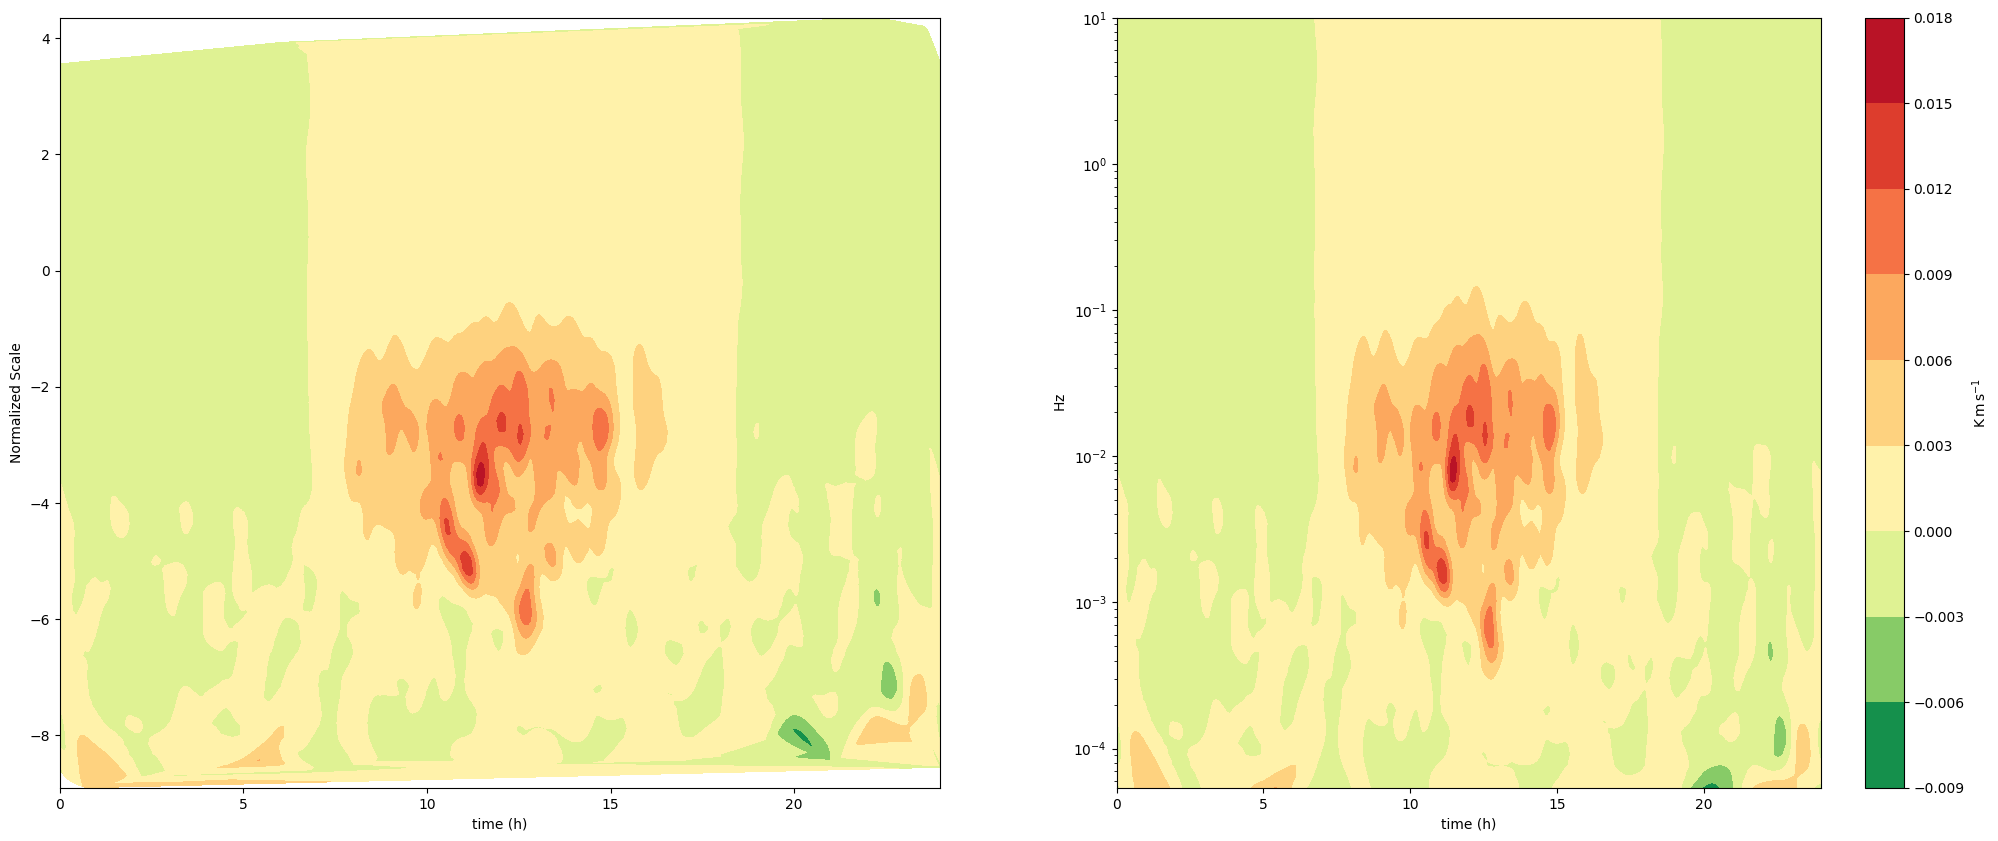

In [23]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(25,10))
label_z=label_T_rawflux
Z=decomp_T
(ax1,tric)=plot_tricontourf(ax1,t[mask_nomean],η[mask_nomean],Z[mask_nomean];label_x=label_time,label_y="Normalized Scale");
(ax2,c)=plot_contour(ax2,time_h[time_sampling],freq_peak[1:end-1],Z[:,1:end-1]');
fig.colorbar(c,label=label_z);

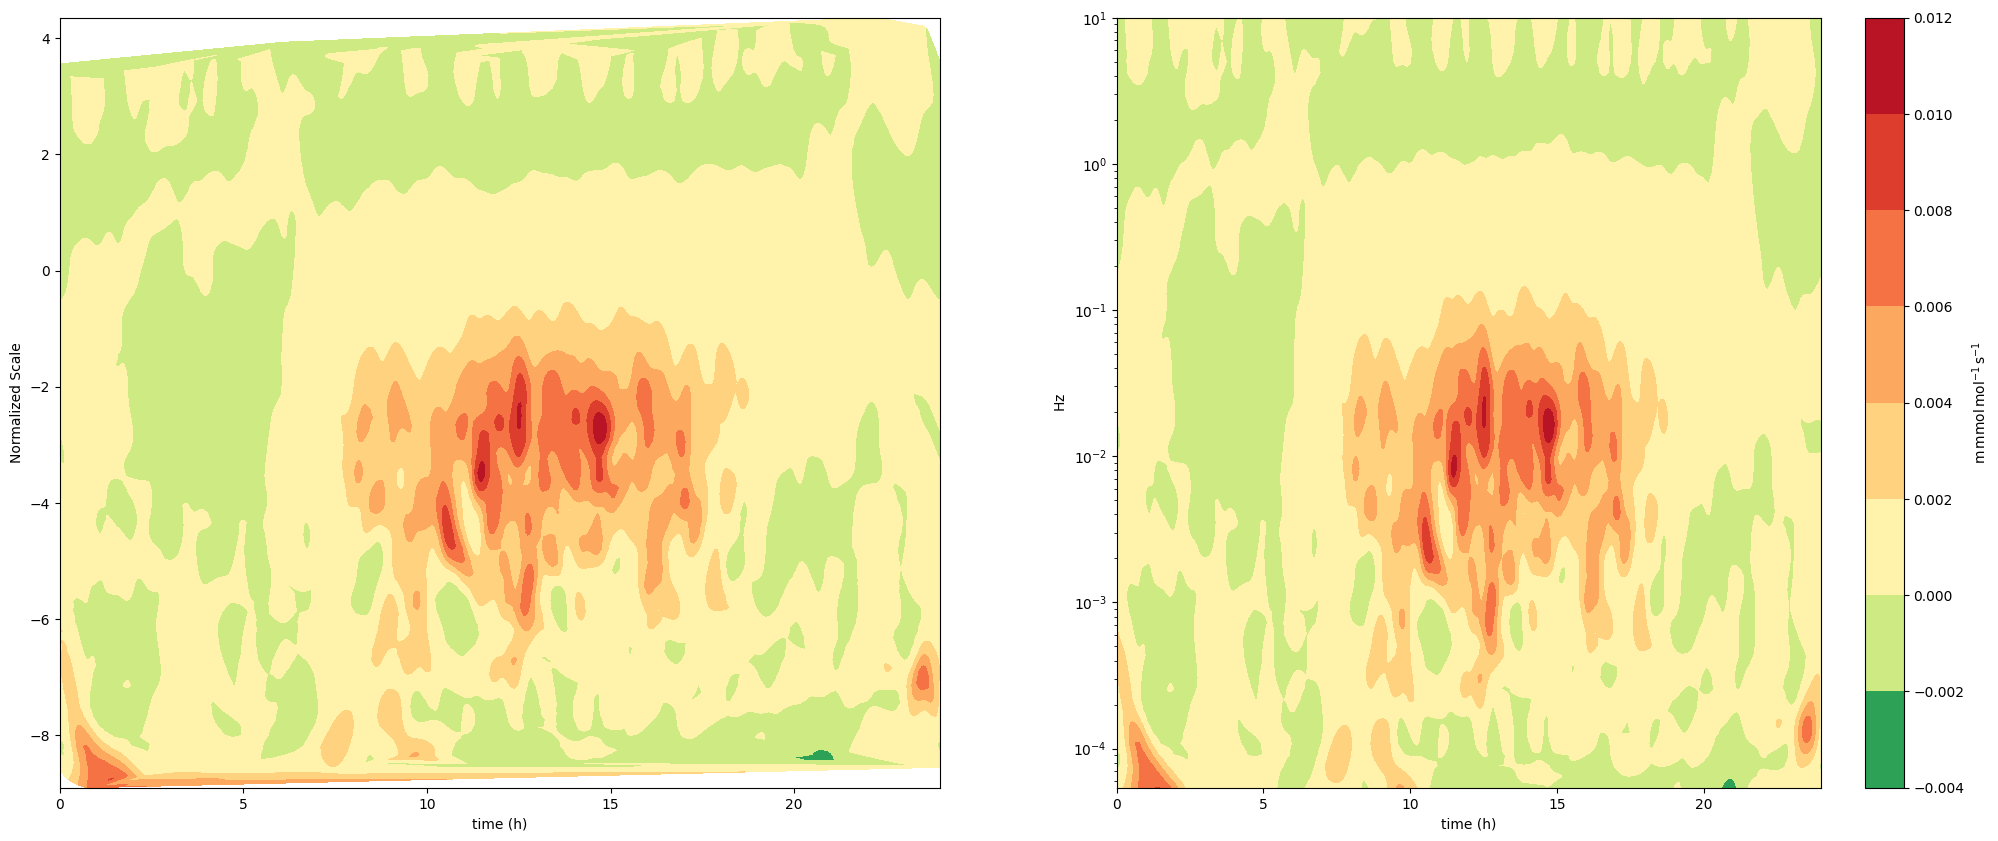

In [24]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(25,10))
label_z=label_h2o_rawflux
Z=decomp_H2O
(ax1,tric)=plot_tricontourf(ax1,t[mask_nomean],η[mask_nomean],Z[mask_nomean];label_x=label_time,label_y="Normalized Scale");
(ax2,c)=plot_contour(ax2,time_h[time_sampling],freq_peak[1:end-1],Z[:,1:end-1]');
fig.colorbar(c,label=label_z);

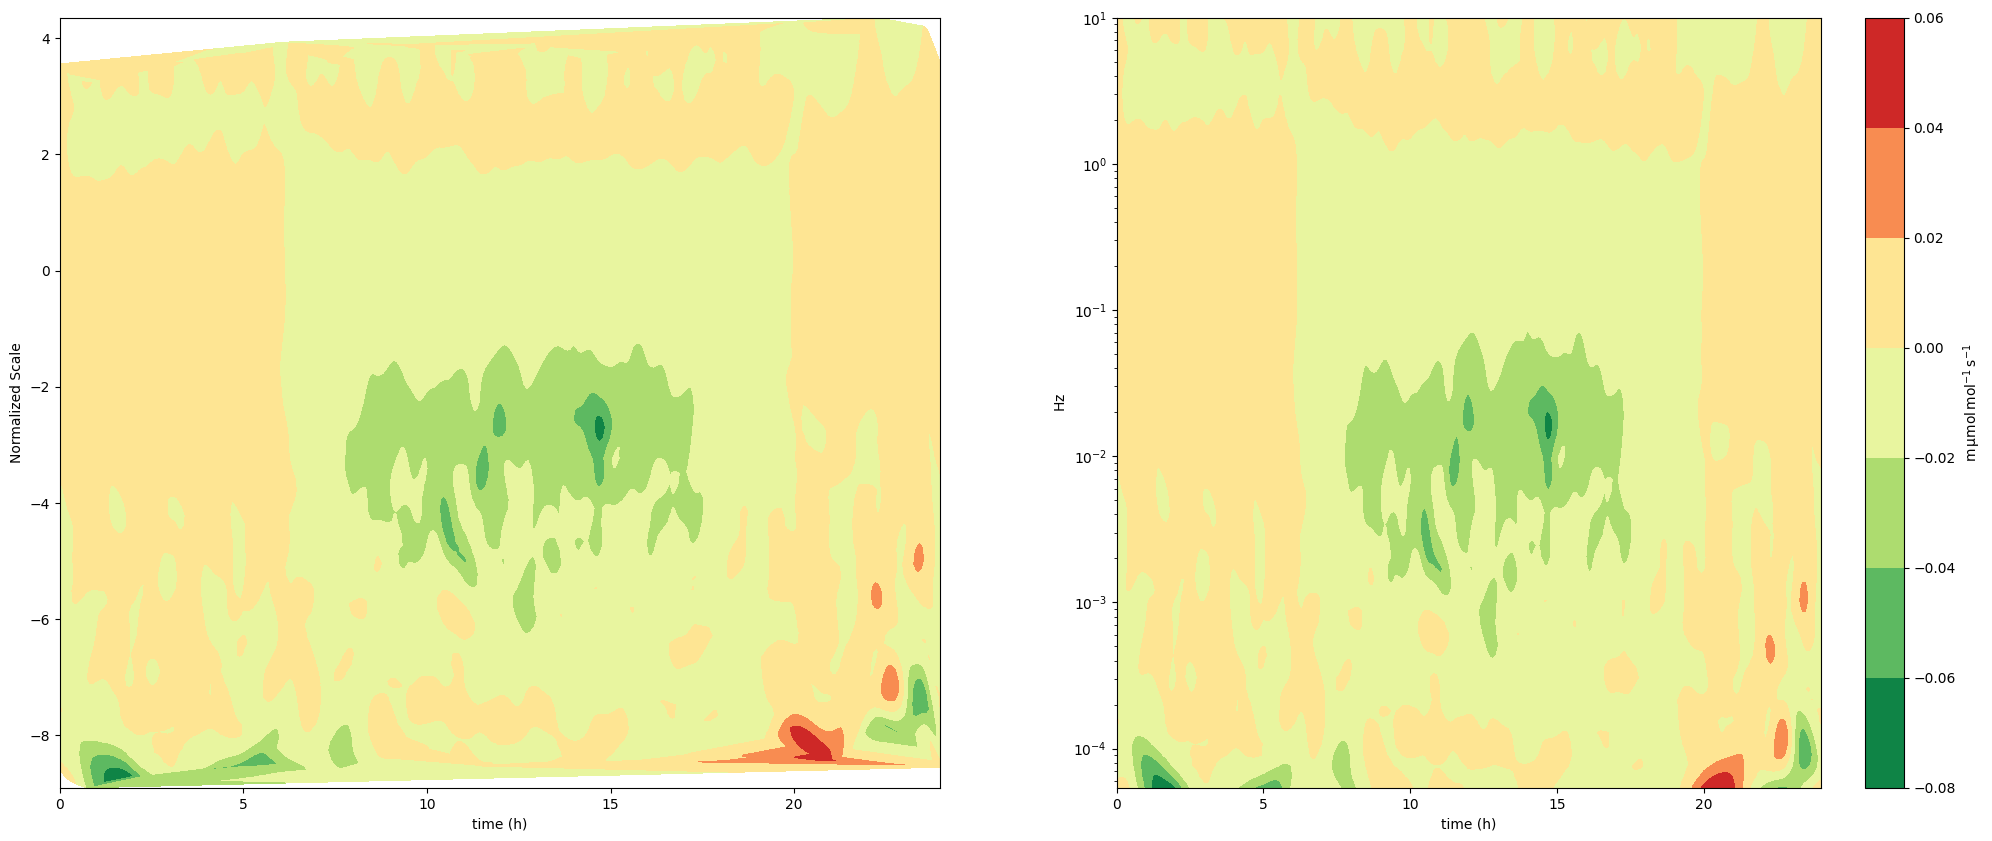

In [25]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(25,10))
label_z=label_co2_rawflux
Z=decomp_CO2
(ax1,tric)=plot_tricontourf(ax1,t[mask_nomean],η[mask_nomean],Z[mask_nomean];label_x=label_time,label_y="Normalized Scale");
(ax2,c)=plot_contour(ax2,time_h[time_sampling],freq_peak[1:end-1],Z[:,1:end-1]');
fig.colorbar(c,label=label_z);

### Conclusion
 - **We clearly identify a region of time-scale in which the flux is concentrated, however there is also high variations of the flux at lower and intermediate scales**
 - **It is necessary to take into account the effect of the wind on the perceive dimension of the eddy in order to straighten the flux along the time axis**

# Assimilation of time-scale flux to time flux

In [26]:
# Prepare density signal
time_params_density=(kernel_type=:gaussian,kernel_dim=kernel_dim,kernel_params=[60*60*fs/work_dim],Δt=Δt);
density = compute_density(P,T,time_params_density);

## Simple Mask Example: Reject `n` first frequency bands from the decomposition
We naively reject the first `n` frequency bands (+ the lowpass) from the decomposition.

In [27]:
n=10
mask_nolp=copy(mask)
mask_nolp[:,(end-n):end] .= false;

F_T,units_T=time_integrate_flux(decomp_T,mask_nomean,density,:SensibleHeat)
F_T_lp,_=time_integrate_flux(decomp_T,mask_nolp,density,:SensibleHeat)

F_H2O,units_H2O=time_integrate_flux(decomp_H2O,mask_nomean,density,:LatentHeat)
F_H2O_lp,units_H2O=time_integrate_flux(decomp_H2O,mask_nolp,density,:LatentHeat)

F_CO2,units_CO2=time_integrate_flux(decomp_CO2,mask_nomean,density,:CO2);
F_CO2_lp,units_CO2=time_integrate_flux(decomp_CO2,mask_nolp,density,:CO2);

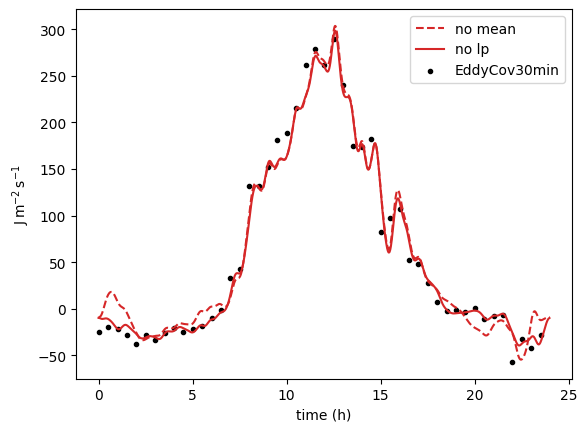

In [28]:
plot(time_h[time_sampling],F_T,color="tab:red",label="no mean","--")
plot(time_h[time_sampling],F_T_lp,color="tab:red",label="no lp","-")
scatter(time_EP,H_UNCORR,color="black",label="EddyCov30min",marker=".")
legend()
xlabel(label_time)
ylabel(latexify(units_T));

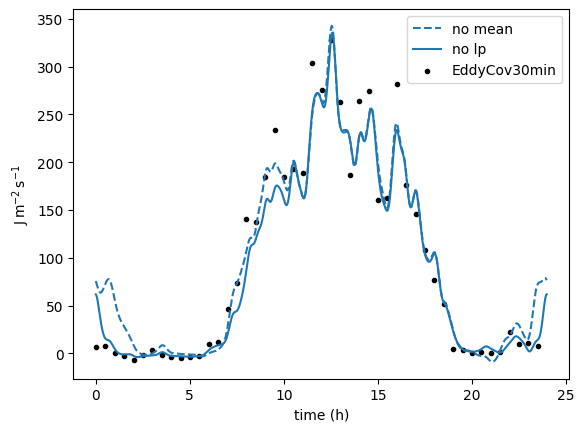

In [29]:
plot(time_h[time_sampling],F_H2O,color="tab:blue",label="no mean","--")
plot(time_h[time_sampling],F_H2O_lp,color="tab:blue",label="no lp","-")
scatter(time_EP,LE_UNCORR,color="black",label="EddyCov30min",marker=".")
legend()
xlabel(label_time)
ylabel(latexify(units_H2O));

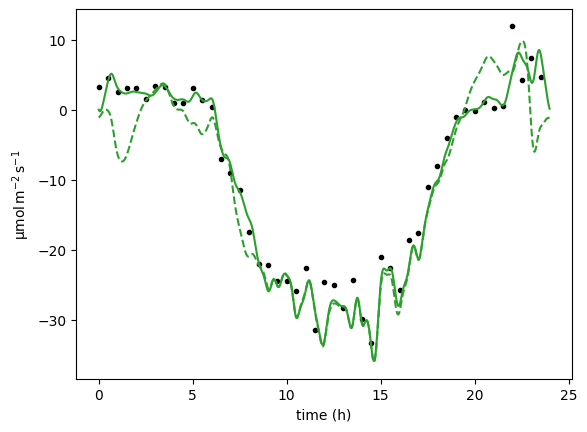

In [30]:
plot(time_h[time_sampling],F_CO2,color="tab:green",label="no mean","--")
plot(time_h[time_sampling],F_CO2_lp,color="tab:green",label="no lp","-")
scatter(time_EP,FC_UNCORR,color="black",label="EddyCov30min",marker=".")
xlabel(label_time)
ylabel(latexify(units_CO2));

# Turbulent transport extraction

## Visualisation of the amplitude of the vertical component of the Reynold's tensor in time-scale space
The amplitude of the vertical component of the Reynold's tensor decomposed in time-scale space is
$$
\tau_w(t,\xi)= \overline{uw}(t,\xi)^2 + \overline{vw}(t,\xi)^2 + \overline{ww}(t,\xi)^2
$$
where $\overline{xy}(t,\xi)^2$ is the decomposition of the covariance of $x$ and $y$ in time-scale space.

Using the log normalized scale/frequency $\eta(t,\xi)=\log \frac{\xi*z}{\overline{|u|^2}(t)}$, we look at $\tau_w(t,\eta(t,\xi))$

In [31]:
time_params_turbu=(kernel_type=:gaussian,kernel_dim=kernel_dim,kernel_params=[60*60*fs/work_dim],Δt=Δt);
_,_,τ_w = amplitude_reynolds_w(U,V,W,time_params_turbu,scale_params);

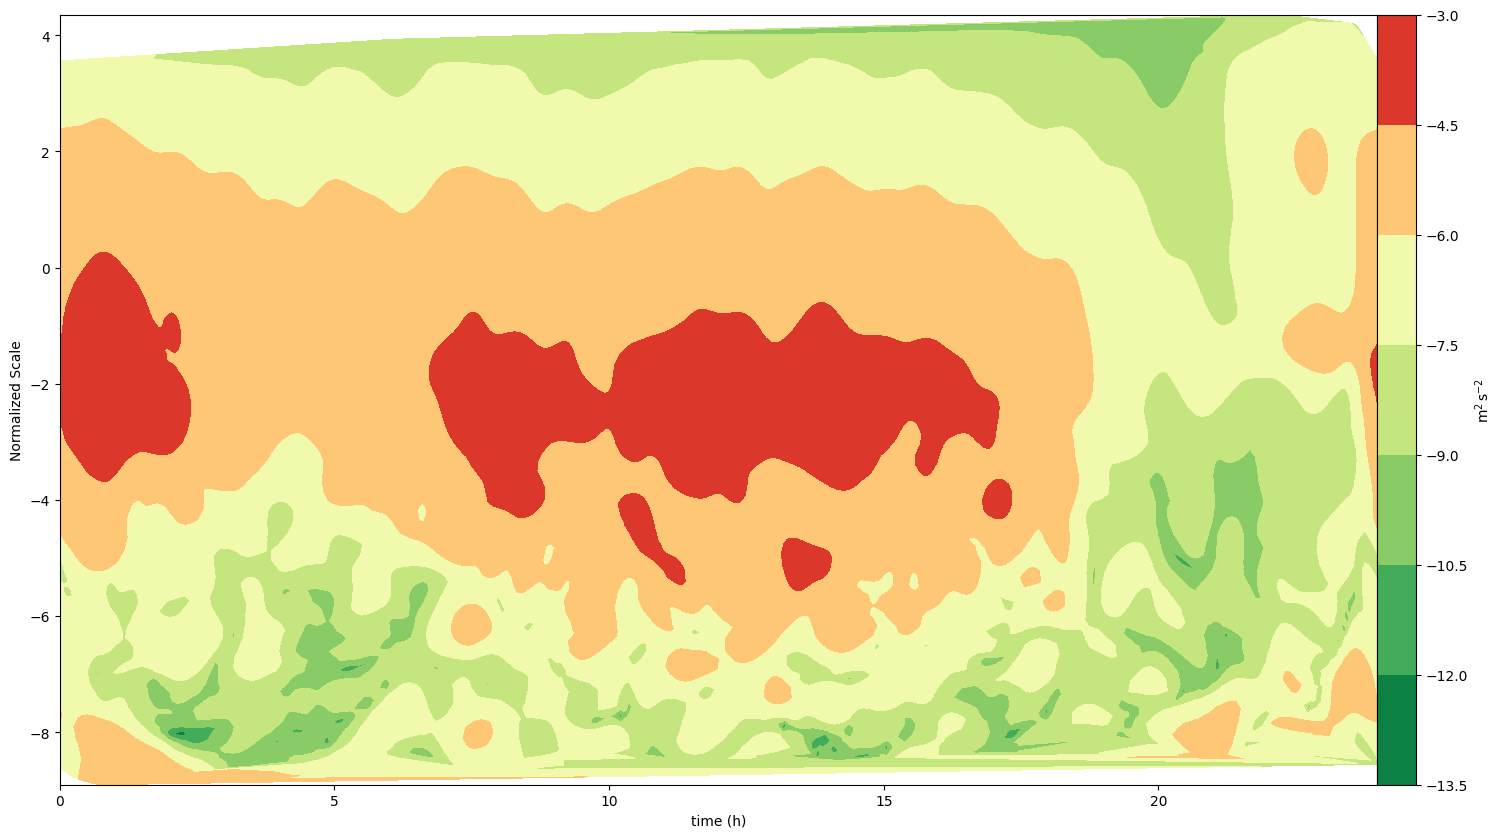

In [32]:
fig=plt.figure(figsize=(20,10))
ax1=plt.axes()
label_z=label_momentum
Z=log.(τ_w)
(ax1,tric)=plot_tricontourf(ax1,t[mask_nomean],η[mask_nomean],Z[mask_nomean];label_x=label_time,label_y="Normalized Scale",norm=norm_mpinf(median(Z)));
fig.colorbar(tric,label=label_z,pad=0);

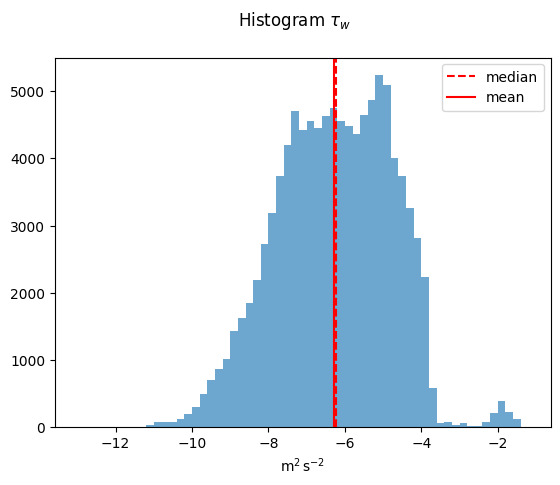

In [33]:
plot_histogram(log.(τ_w[:]); title_str=L" $\tau_w$",label_x=label_momentum,nbins=100);

## Simple Thresholding

In [34]:
threshold=exp(-6)
mask_thresh= turbu_extract_threshold(τ_w;threshold=threshold);
mask_thresh[:,end] .= false; # Make sure that no mean values are captured

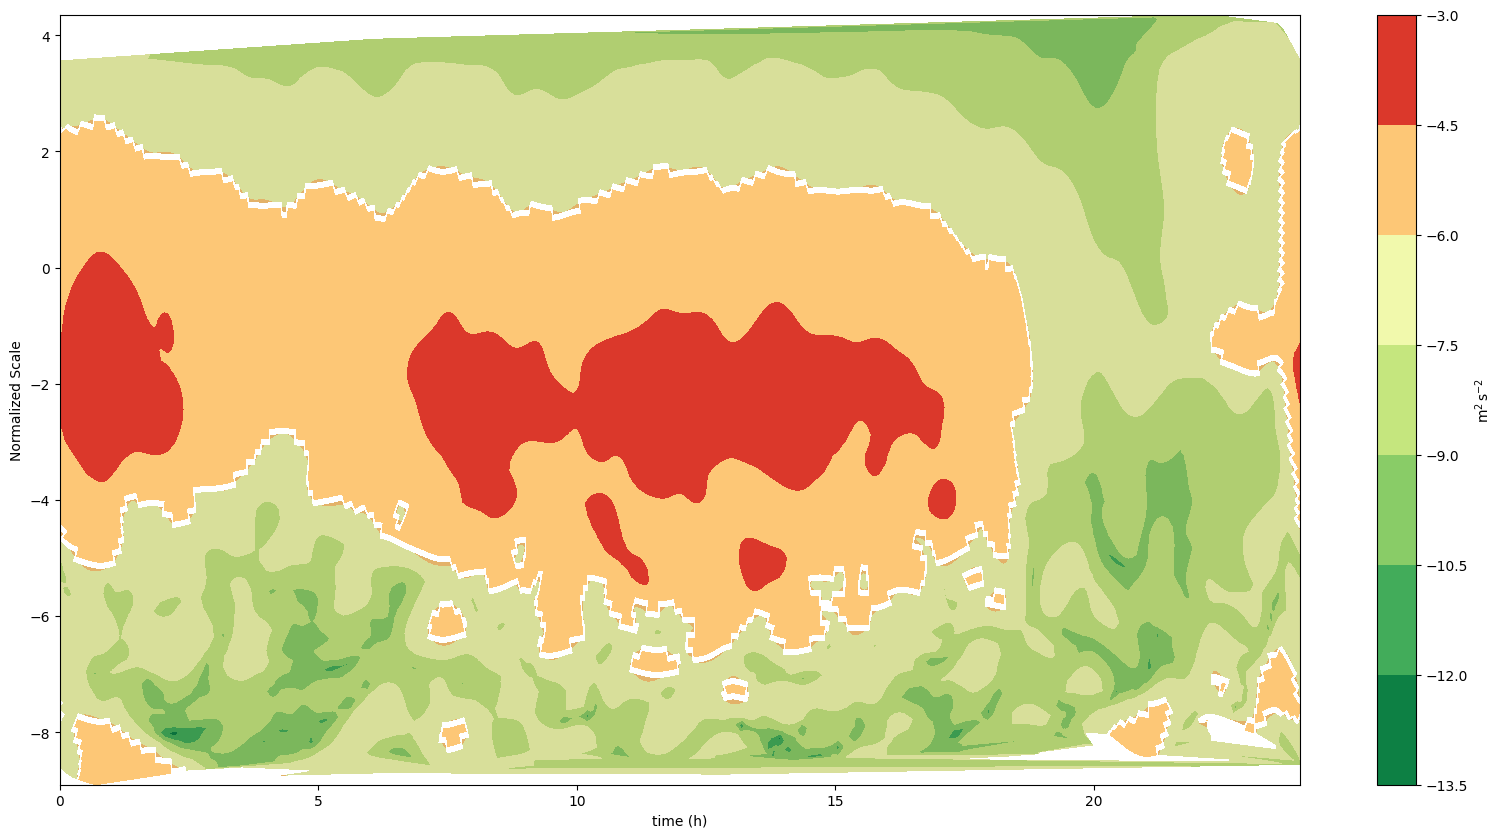

In [35]:
fig=plt.figure(figsize=(20,10))
ax1=plt.axes()
label_z=label_momentum
Z=log.(τ_w)
(ax1,tric)=plot_tricontourf(ax1,t[mask_nomean],η[mask_nomean],Z[mask_nomean];label_x=label_time,label_y="Normalized Scale",norm=norm_mpinf(median(Z)),alphamask=mask_thresh[mask_nomean]);
fig.colorbar(tric,label=label_z);

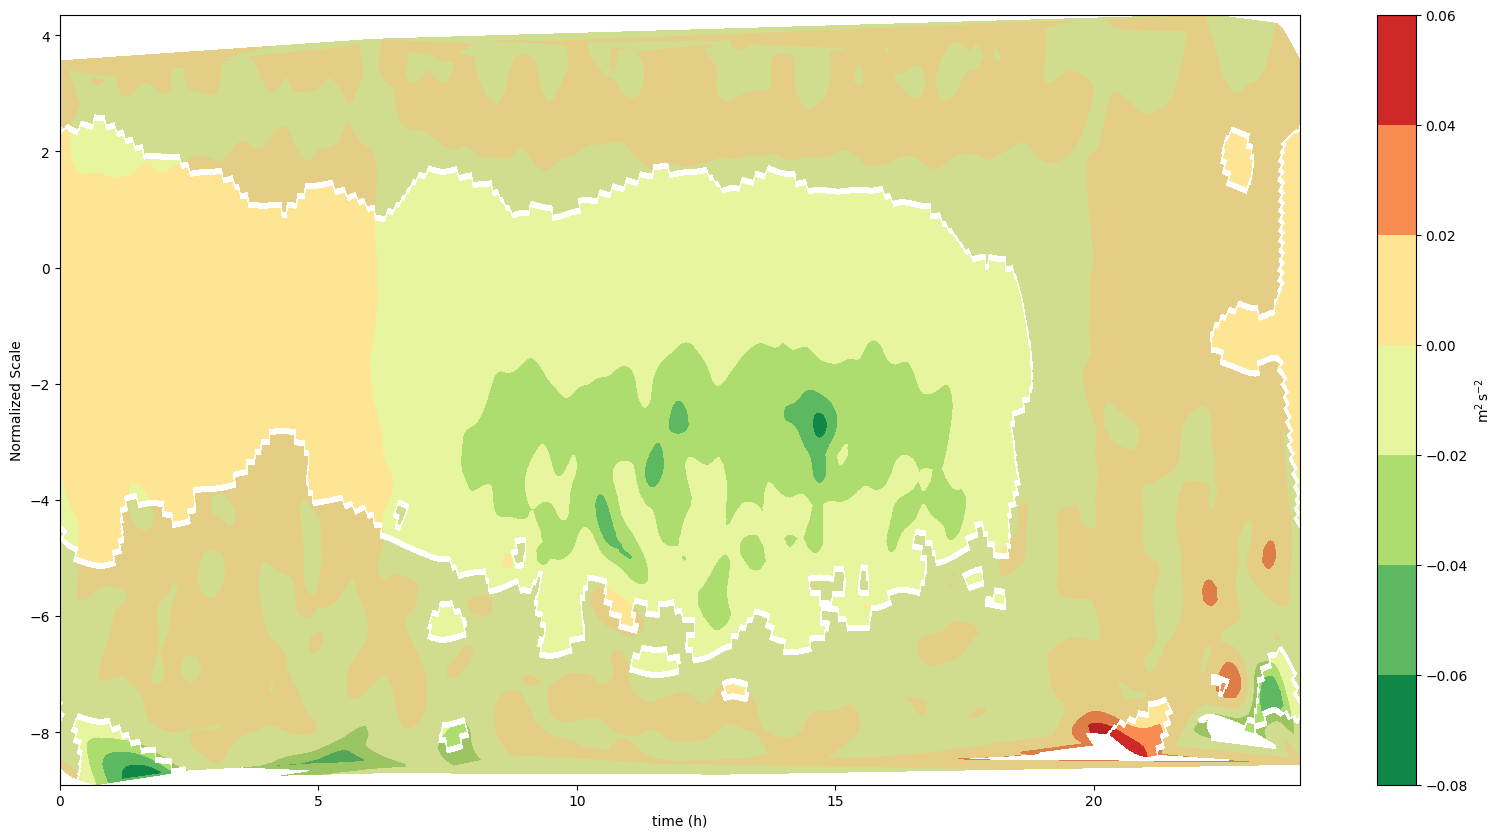

In [36]:
fig=plt.figure(figsize=(20,10))
ax1=plt.axes()
label_z=label_momentum
Z=decomp_CO2
(ax1,tric)=plot_tricontourf(ax1,t[mask_nomean],η[mask_nomean],Z[mask_nomean];label_x=label_time,label_y="Normalized Scale",norm=norm_mpinf(median(Z)),alphamask=mask_thresh[mask_nomean]);
fig.colorbar(tric,label=label_z);

In [37]:
F_T_thresh,_=time_integrate_flux(decomp_T,mask_thresh,density,:SensibleHeat)
F_H2O_thresh,units_H2O=time_integrate_flux(decomp_H2O,mask_thresh,density,:LatentHeat)
F_CO2_thresh,units_CO2=time_integrate_flux(decomp_CO2,mask_thresh,density,:CO2);

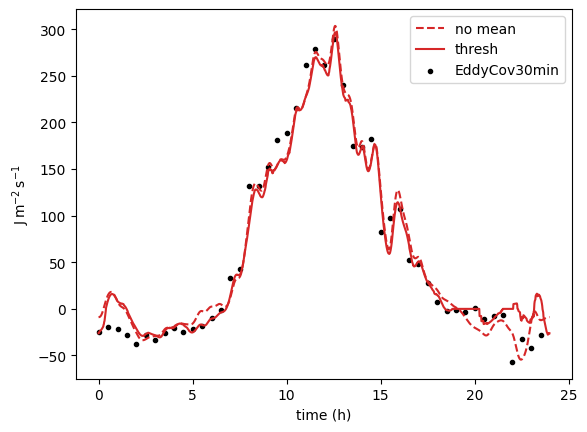

In [38]:
plot(time_h[time_sampling],F_T,color="tab:red",label="no mean","--")
plot(time_h[time_sampling],F_T_thresh,color="tab:red",label="thresh","-")
scatter(time_EP,H_UNCORR,color="black",label="EddyCov30min",marker=".")
legend()
xlabel(label_time)
ylabel(latexify(units_T));

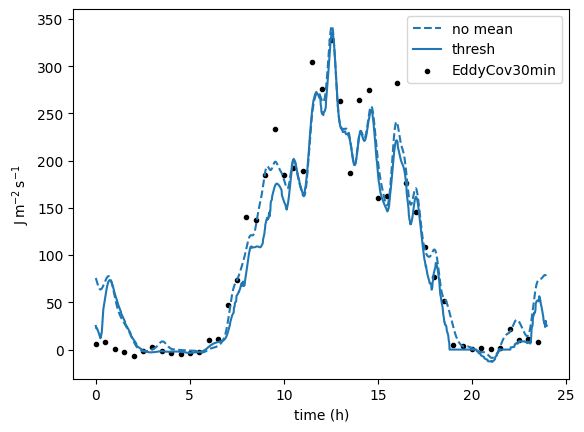

In [39]:
plot(time_h[time_sampling],F_H2O,color="tab:blue",label="no mean","--")
plot(time_h[time_sampling],F_H2O_thresh,color="tab:blue",label="thresh","-")
scatter(time_EP,LE_UNCORR,color="black",label="EddyCov30min",marker=".")
legend()
xlabel(label_time)
ylabel(latexify(units_H2O));

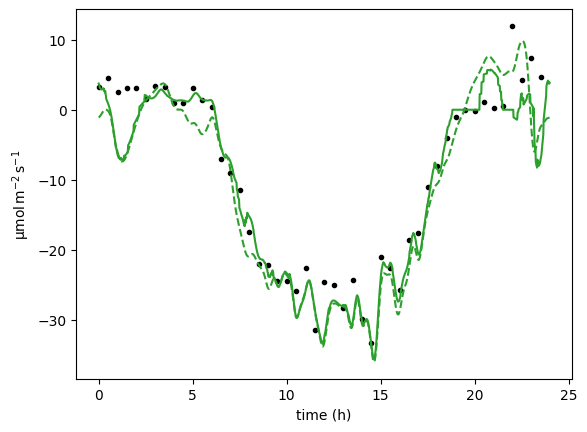

In [40]:
plot(time_h[time_sampling],F_CO2,color="tab:green",label="no mean","--")
plot(time_h[time_sampling],F_CO2_thresh,color="tab:green",label="thresh","-")
scatter(time_EP,FC_UNCORR,color="black",label="EddyCov30min",marker=".")
xlabel(label_time)
ylabel(latexify(units_CO2));

## Laplacian based
We look at the laplacian of $\tau_w$ in order to find regions of high instability. In regions with random fluctuations, we may expect many local minimas over short displacement in time-scale space. Thus, we look at the laplacian to find some interesting regions.

In [41]:
(masks,tau_rey)=turbu_extract_laplacian(τ_w; time_sampling=time_sampling, freq_peak=freq_peak, ref_dist=ref_dist, mean_wind=mean_wind,weighted_laplacian=false)
(X,Y,τ_mapped,Δτ,itp)=tau_rey;

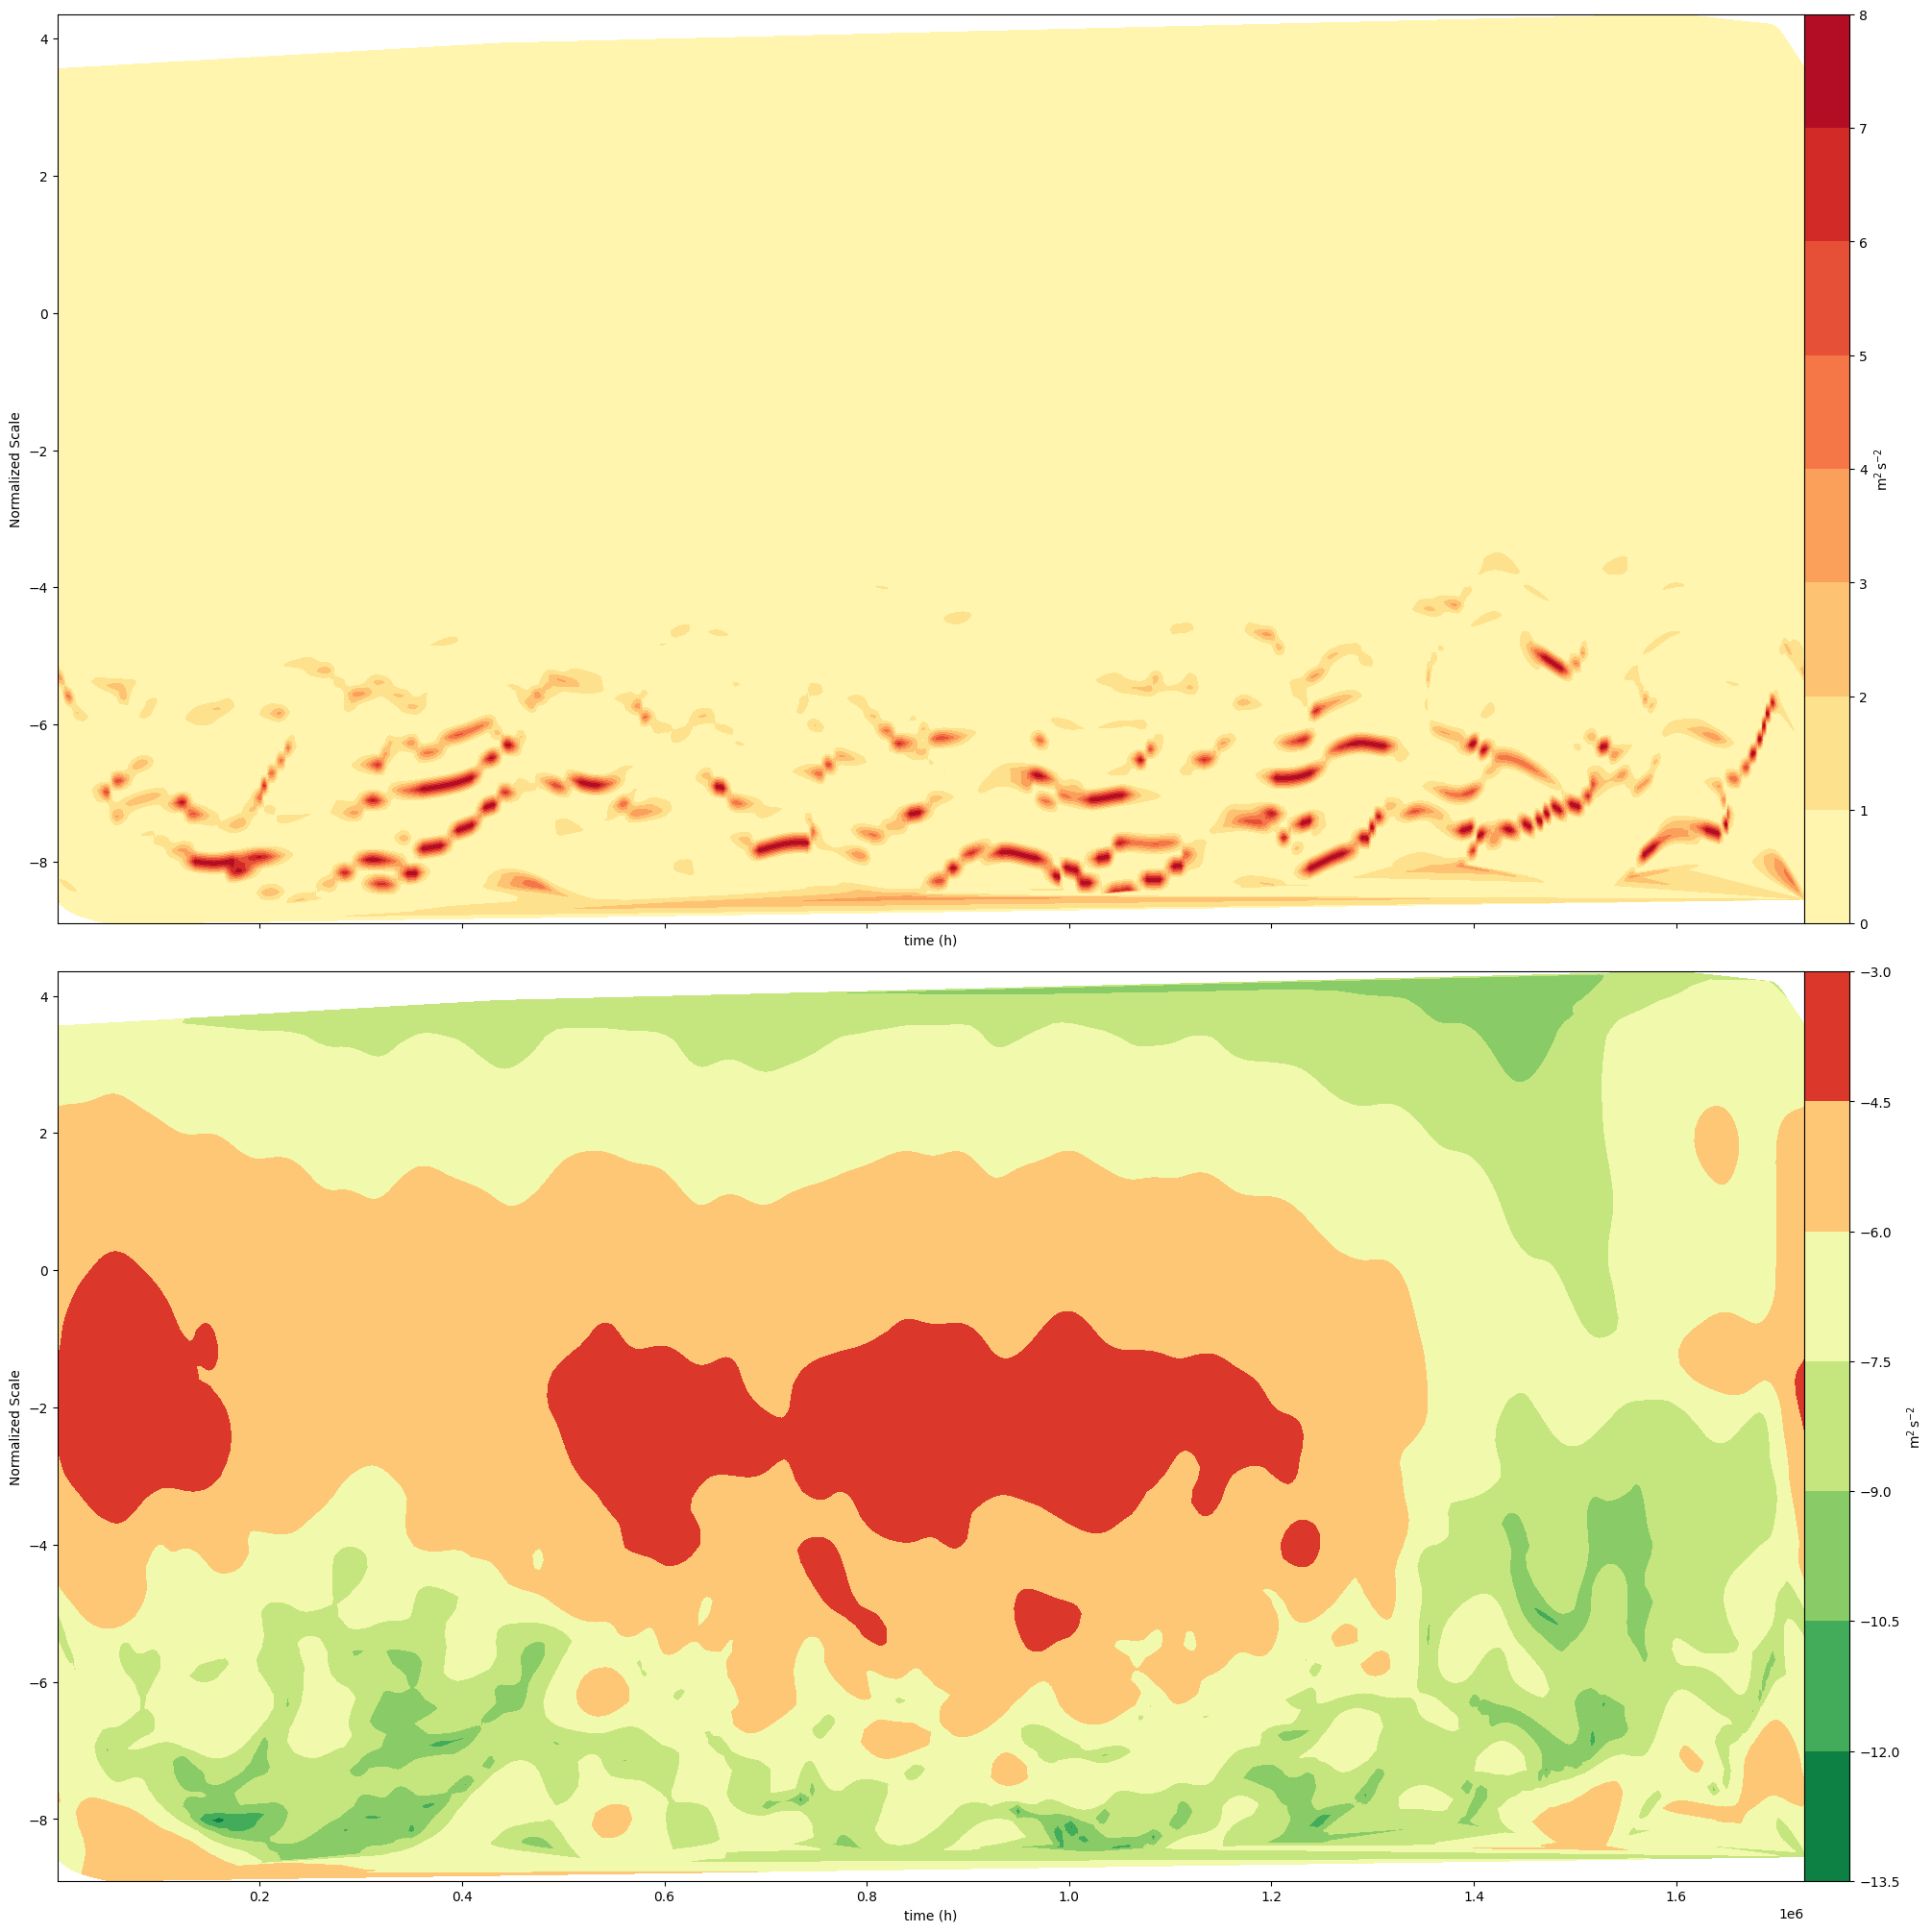

In [42]:
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(20,20),sharex=true,layout="constrained")
label_z=label_momentum
Z=map(x-> x.> 8 ? 8 : max(0,x),Δτ) # Apply some clipping for comparison with others
(ax1,tric)=plot_tricontourf(ax1,X[mask_nomean],Y[mask_nomean],Z[mask_nomean];label_x=label_time,label_y="Normalized Scale",norm=norm_mpinf(0));
plt.colorbar(tric,label=label_z,pad=0);
Z=log.(τ_w)
(ax2,tric)=plot_tricontourf(ax2,X[mask_nomean],Y[mask_nomean],Z[mask_nomean];label_x=label_time,label_y="Normalized Scale",norm=norm_mpinf(median(Z)));
plt.colorbar(tric,label=label_z,pad=0);

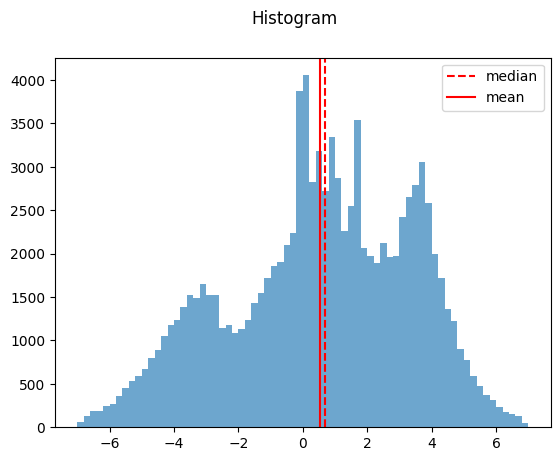

In [43]:
plot_histogram(sign.(Δτ) .* log.(0.001 .+ abs.(Δτ)),nbins=100);

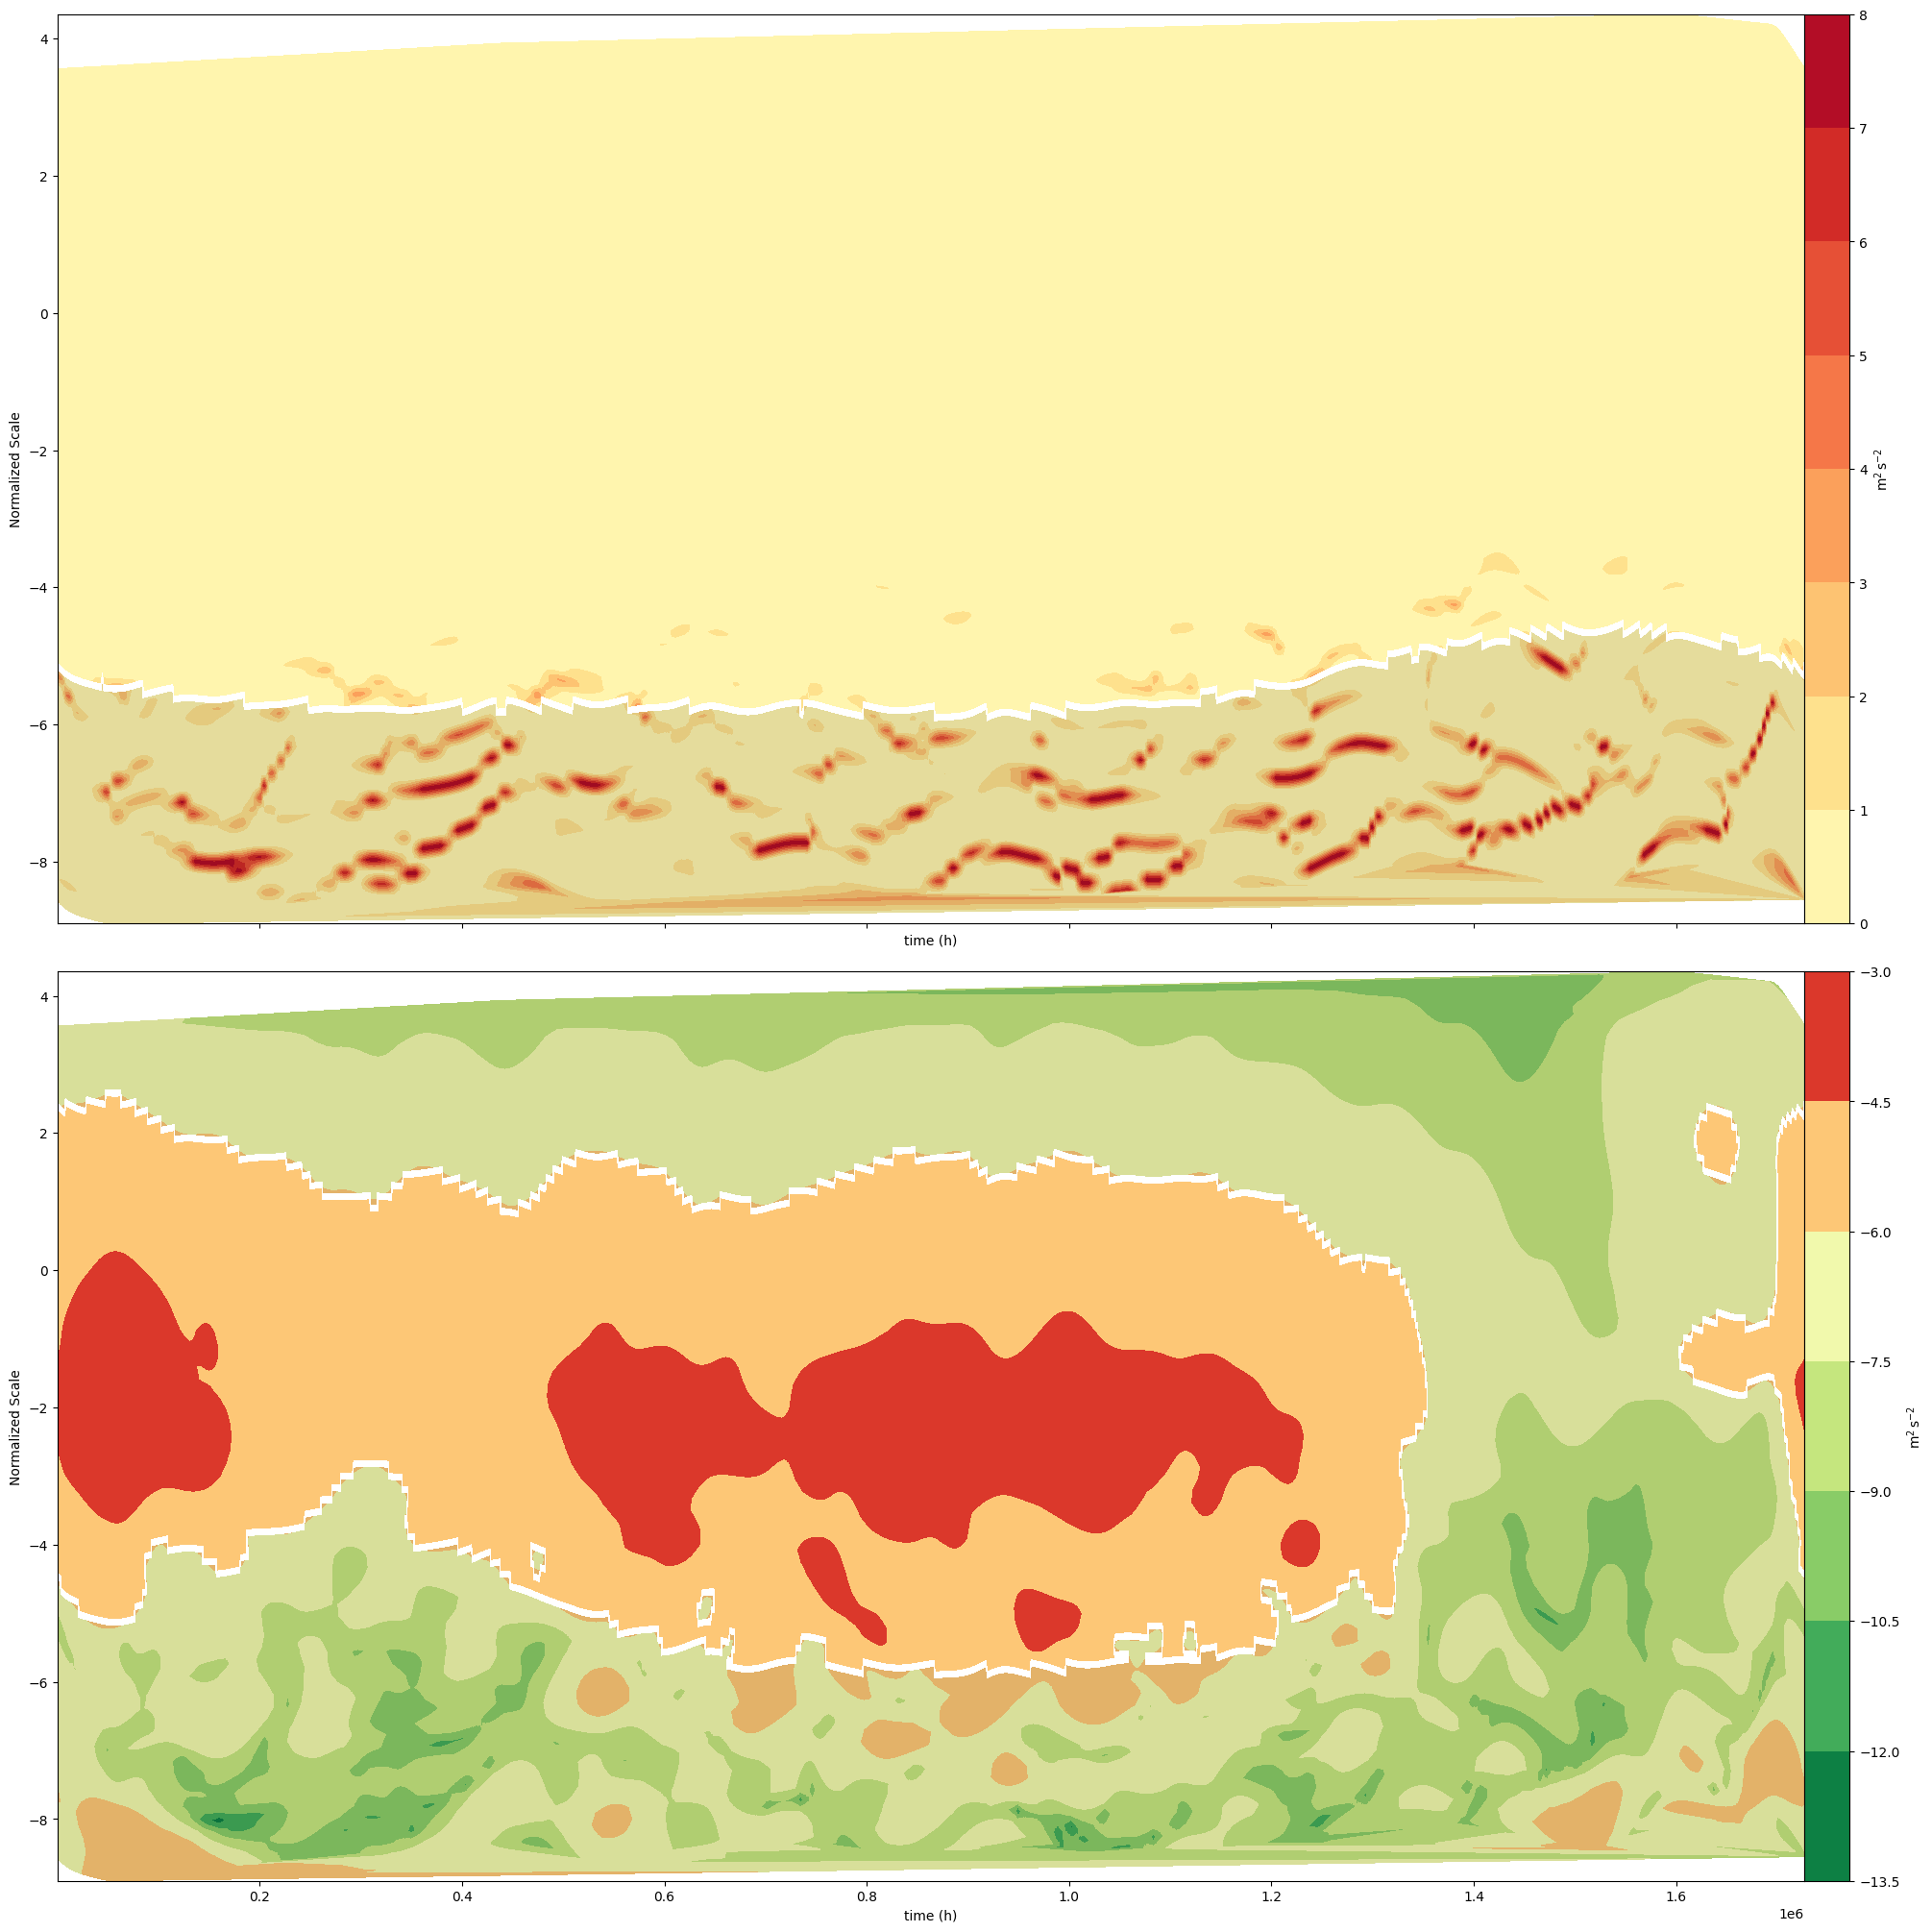

In [44]:
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(20,20),sharex=true,layout="constrained")
label_z=label_momentum
Z=map(x-> x.> 8 ? 8 : max(x,0),Δτ) # Apply some clipping, remove rare events + negative values
(ax1,tric)=plot_tricontourf(ax1,X[mask_nomean],Y[mask_nomean],Z[mask_nomean];label_x=label_time,label_y="Normalized Scale",norm=norm_mpinf(0),alphamask=masks[2][mask_nomean]);
plt.colorbar(tric,label=label_z,pad=0);
Z=log.(τ_w)
(ax2,tric)=plot_tricontourf(ax2,X[mask_nomean],Y[mask_nomean],Z[mask_nomean];label_x=label_time,label_y="Normalized Scale",norm=norm_mpinf(median(Z)),alphamask=masks[3][mask_nomean]);
plt.colorbar(tric,label=label_z,pad=0);

In [45]:
F_T_thresh,_=time_integrate_flux(decomp_T,masks[3],density,:SensibleHeat)
F_H2O_thresh,units_H2O=time_integrate_flux(decomp_H2O,masks[3],density,:LatentHeat)
F_CO2_thresh,units_CO2=time_integrate_flux(decomp_CO2,masks[3],density,:CO2);

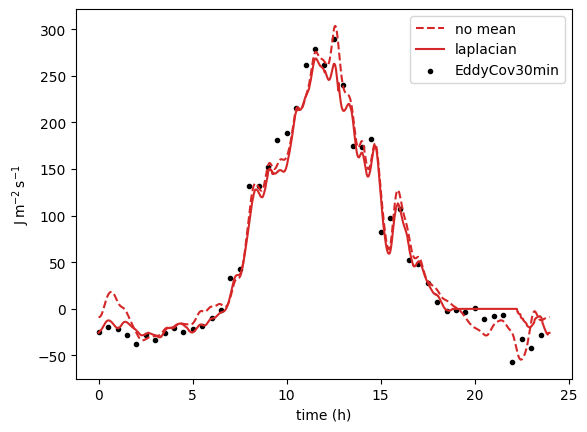

In [46]:
plot(time_h[time_sampling],F_T,color="tab:red",label="no mean","--")
plot(time_h[time_sampling],F_T_thresh,color="tab:red",label="laplacian","-")
scatter(time_EP,H_UNCORR,color="black",label="EddyCov30min",marker=".")
legend()
xlabel(label_time)
ylabel(latexify(units_T));

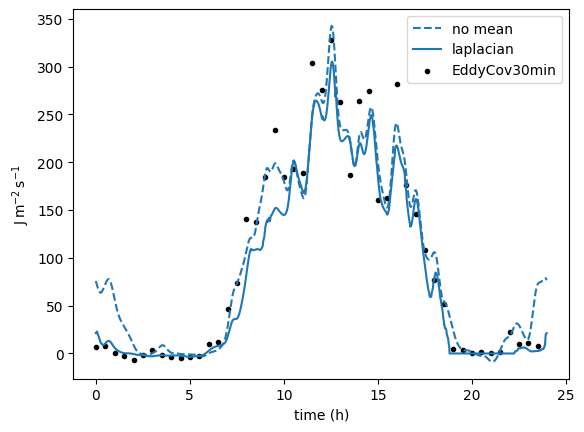

In [47]:
plot(time_h[time_sampling],F_H2O,color="tab:blue",label="no mean","--")
plot(time_h[time_sampling],F_H2O_thresh,color="tab:blue",label="laplacian","-")
scatter(time_EP,LE_UNCORR,color="black",label="EddyCov30min",marker=".")
legend()
xlabel(label_time)
ylabel(latexify(units_H2O));

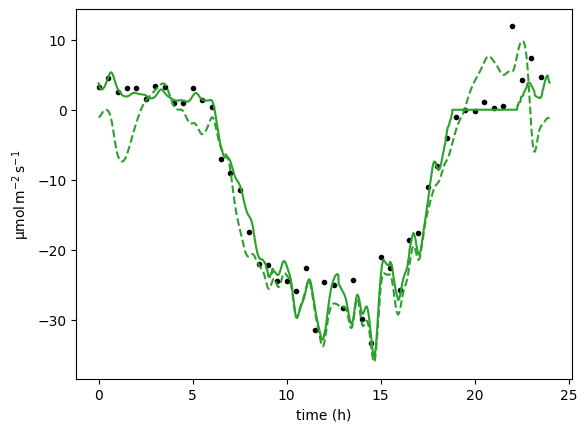

In [48]:
plot(time_h[time_sampling],F_CO2,color="tab:green",label="no mean","--")
plot(time_h[time_sampling],F_CO2_thresh,color="tab:green",label="laplacian","-")
scatter(time_EP,FC_UNCORR,color="black",label="EddyCov30min",marker=".")
xlabel(label_time)
ylabel(latexify(units_CO2));

## Diffusion based (WIP)

The idea is to start with with an initial guess of the turbulence at $\eta=0$ and then use a transition kernel with a 9-point grid graph over $\tau_w$ to drive the initial guess towards high intensity regions around $\eta=0$.

In [49]:
(gg,Δv,Σ,(X,Y,τ_mapped))=turbu_extract_diffusion(τ_w; time_sampling=time_sampling, freq_peak=freq_peak, ref_dist=ref_dist, mean_wind=mean_wind);

Not Fully implemented yet


┌ Warning: nothing
└ @ TurbulenceFlux ~/Documents/PostDocFlux/TurbulenceFlux.jl/src/flux.jl:320


# Sensibility analysis